# Giảm chiều dữ liệu MNIST – So sánh Baseline vs Sau giảm chiều

**Đề tài:**
- Thực hiện giảm chiều (PCA) cho bộ MNIST.
- Đánh giá **baseline** (dữ liệu gốc) và **sau giảm chiều**.
- So sánh: **tiêu thụ bộ nhớ**, **thời gian xử lý** (fit + predict), **hao hụt độ chính xác**.

## 1. Import và tải dữ liệu

In [13]:
import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

from lib import (
    MNISTDataLoader,
    MNISTClassifier,
    DimensionalityReducer,
    measure_array_memory_mb,
    run_and_measure_seconds,
    plot_comparison_reduction,
    print_comparison_table,
    plot_confusion_matrix,
    print_classification_report,
)
import matplotlib.pyplot as plt

In [14]:
loader = MNISTDataLoader(normalize=True, flatten=True)
X_train, y_train, X_test, y_test = loader.load()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Số chiều gốc: {X_train.shape[1]}")

X_train: (60000, 784), X_test: (10000, 784)
Số chiều gốc: 784


## 2. Baseline – Đánh giá trên dữ liệu gốc (784 chiều)

In [15]:
baseline_memory_mb = measure_array_memory_mb(X_train)
print(f"Bộ nhớ X_train (baseline): {baseline_memory_mb:.4f} MB")

Bộ nhớ X_train (baseline): 358.8867 MB


In [16]:
clf_baseline = MNISTClassifier(model_type="logistic", random_state=42)

_, time_fit_baseline = run_and_measure_seconds(lambda: clf_baseline.fit(X_train, y_train))
_, time_predict_baseline = run_and_measure_seconds(lambda: clf_baseline.predict(X_test))

acc_baseline = clf_baseline.score(X_test, y_test)

baseline_metrics = {
    "memory_mb": baseline_memory_mb,
    "time_fit_s": time_fit_baseline,
    "time_predict_s": time_predict_baseline,
    "accuracy": acc_baseline,
}
print(f"Baseline - Fit: {time_fit_baseline:.4f} s, Predict: {time_predict_baseline:.4f} s, Accuracy: {acc_baseline:.4f}")

Baseline - Fit: 39.9076 s, Predict: 0.0267 s, Accuracy: 0.9257


## 3. Giảm chiều bằng PCA

In [17]:
n_components = 0.95
reducer = DimensionalityReducer(n_components=n_components, random_state=42)
X_train_reduced = reducer.fit_transform(X_train)
X_test_reduced = reducer.transform(X_test)

print(f"Số chiều sau giảm: {reducer.n_components_}")
print(f"Tổng phương sai giữ lại: {reducer.total_explained_variance_ratio():.4f}")

Số chiều sau giảm: 154
Tổng phương sai giữ lại: 0.9502


In [18]:
reduced_memory_mb = measure_array_memory_mb(X_train_reduced)
print(f"Bộ nhớ X_train (sau giảm chiều): {reduced_memory_mb:.4f} MB")

Bộ nhớ X_train (sau giảm chiều): 70.4956 MB


## 4. Đánh giá trên dữ liệu sau giảm chiều

In [19]:
clf_reduced = MNISTClassifier(model_type="logistic", random_state=42)

_, time_fit_reduced = run_and_measure_seconds(lambda: clf_reduced.fit(X_train_reduced, y_train))
_, time_predict_reduced = run_and_measure_seconds(lambda: clf_reduced.predict(X_test_reduced))

acc_reduced = clf_reduced.score(X_test_reduced, y_test)

reduced_metrics = {
    "memory_mb": reduced_memory_mb,
    "time_fit_s": time_fit_reduced,
    "time_predict_s": time_predict_reduced,
    "accuracy": acc_reduced,
}
print(f"Sau giảm chiều - Fit: {time_fit_reduced:.4f} s, Predict: {time_predict_reduced:.4f} s, Accuracy: {acc_reduced:.4f}")

Sau giảm chiều - Fit: 3.8887 s, Predict: 0.0128 s, Accuracy: 0.9229


## 5. So sánh: Bộ nhớ, Thời gian, Độ chính xác

In [20]:
print_comparison_table(baseline_metrics, reduced_metrics, reduced_name="Sau giảm chiều (PCA)")

BẢNG SO SÁNH: BASELINE vs SAU GIẢM CHIỀU
Chỉ số                        Baseline Sau giảm chiều (PCA)   Chênh lệch
------------------------------------------------------------
Bộ nhớ (MB)                   358.8867      70.4956      +80.36%
Thời gian fit (s)              39.9076       3.8887
Thời gian predict (s)           0.0267       0.0128
Độ chính xác (%)                 92.57        92.29       +0.30% (hao hụt)


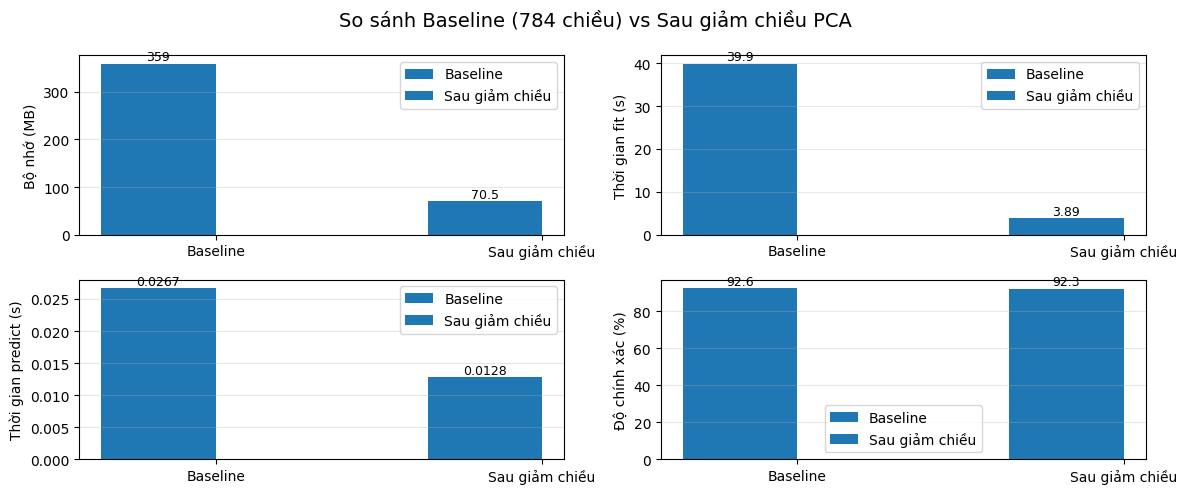

In [21]:
fig = plot_comparison_reduction(
    baseline_metrics,
    reduced_metrics,
    title="So sánh Baseline (784 chiều) vs Sau giảm chiều PCA",
)
plt.show()

## 6. Báo cáo phân lớp và Confusion Matrix (sau giảm chiều)

In [22]:
y_pred_reduced = clf_reduced.predict(X_test_reduced)
class_names = loader.get_class_names()

print("Báo cáo phân lớp (mô hình trên dữ liệu sau giảm chiều):")
print_classification_report(y_test, y_pred_reduced, class_names=class_names)

Báo cáo phân lớp (mô hình trên dữ liệu sau giảm chiều):
              precision    recall  f1-score   support

           0     0.9512    0.9745    0.9627       980
           1     0.9652    0.9780    0.9716      1135
           2     0.9217    0.9012    0.9113      1032
           3     0.9006    0.9059    0.9033      1010
           4     0.9281    0.9328    0.9304       982
           5     0.8977    0.8655    0.8813       892
           6     0.9391    0.9499    0.9445       958
           7     0.9329    0.9202    0.9265      1028
           8     0.8815    0.8860    0.8838       974
           9     0.9012    0.9039    0.9025      1009

    accuracy                         0.9229     10000
   macro avg     0.9219    0.9218    0.9218     10000
weighted avg     0.9227    0.9229    0.9227     10000



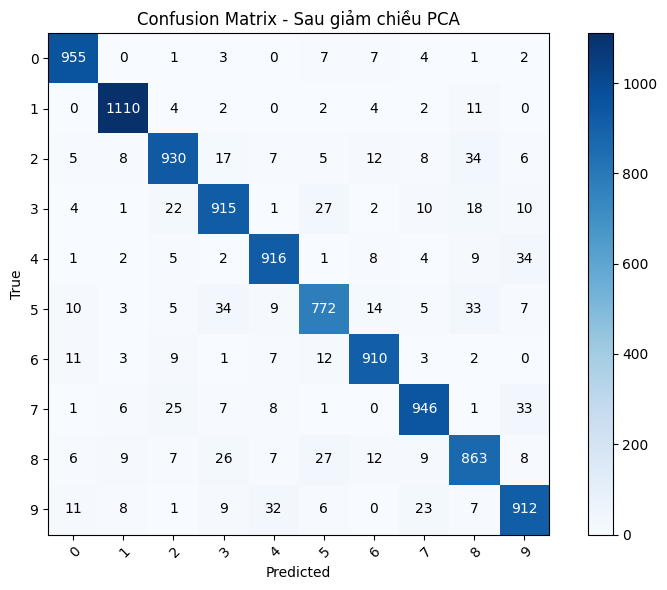

In [23]:
fig = plot_confusion_matrix(y_test, y_pred_reduced, class_names=class_names, title="Confusion Matrix - Sau giảm chiều PCA")
plt.show()

## 7. (Tùy chọn) Thử nhiều mức giảm chiều

So sánh hao hụt độ chính xác và tiết kiệm bộ nhớ khi thay đổi số chiều PCA.

In [ ]:
results_1 = []
for n_comp in [0.99, 0.95, 0.90, 0.85, 0.80]:
    r = DimensionalityReducer(n_components=n_comp, random_state=42)
    X_tr = r.fit_transform(X_train)
    X_te = r.transform(X_test)
    mem = measure_array_memory_mb(X_tr)
    clf = MNISTClassifier(model_type="logistic", random_state=42)
    clf.fit(X_tr, y_train)
    acc = clf.score(X_te, y_test)
    results_1.append({"n_components": n_comp, "dims": r.n_components_, "memory_mb": mem, "accuracy": acc})

results_2 = []
for n_comp in [300, 154, 100, 50, 30]:
    r = DimensionalityReducer(n_components=n_comp, random_state=42)
    X_tr = r.fit_transform(X_train)
    X_te = r.transform(X_test)
    mem = measure_array_memory_mb(X_tr)
    clf = MNISTClassifier(model_type="logistic", random_state=42)
    clf.fit(X_tr, y_train)
    acc = clf.score(X_te, y_test)
    results_2.append({"n_components": n_comp, "dims": r.n_components_, "memory_mb": mem, "accuracy": acc})


print(f"{'Số đặc trưng':<20} | {'Số chiều':<10} | {'Bộ nhớ (MB)':<15} | {'Accuracy':<10}")
for row in results_1:
    print(f"{row['n_components']:<20} | {row['dims']:<10} | {row['memory_mb']:08.4f}        | {row['accuracy']:.4f}")

print("\n")

print(f"{'Độ chính xác':<20} | {'Số chiều':<10} | {'Bộ nhớ (MB)':<15} | {'Accuracy':<10}")
for row in results_2:
    print(f"{row['n_components']:<20} | {row['dims']:<10} | {row['memory_mb']:08.4f}        | {row['accuracy']:.4f}")

số đặc trưng         | Số chiều   | Bộ nhớ (MB)     | Accuracy  
0.99                 | 331        | 151.5198        | 0.9252
0.95                 | 154        | 070.4956        | 0.9229
0.9                  | 87         | 039.8254        | 0.9194
0.85                 | 59         | 027.0081        | 0.9164
0.8                  | 44         | 020.1416        | 0.9104
Độ chính xác         | Số chiều   | Bộ nhớ (MB)     | Accuracy  
300                  | 300        | 137.3291        | 0.9243
154                  | 154        | 070.4956        | 0.9229
100                  | 100        | 045.7764        | 0.9218
50                   | 50         | 022.8882        | 0.9117
30                   | 30         | 013.7329        | 0.8960
